# <p align = "center"> Conformation Analysis </p>
## <p align = "center"> rmsd | rmsf | angles </p>


In [1]:
from pathlib import Path
rootdir = Path("../../../..").resolve()
import sys
sys.path.insert(0, str(rootdir) )
from typing import Callable, Generator

import gemmi 
import parasail
import numpy as np
from rdkit import Chem

from xaidar.data.molecModels import get_pdb_stats, sele_pdb, sele_Lig, get_res_CoM
from xaidar.data.molecModels import flatten_pdb, sele_AA, createPDB, get_atom_coord

- ## Load Proteins and Fragments of Interest

In [42]:
from xaidar.data.protocols import load_and_filter_Proteins, extract_lig_from_prot
from xaidar.data.molecModels import get_res_CoM, sele_pdb, sele_Lig, flatten_pdb, sele_closest_Chain, get_pdb_stats
# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"
ref_dir = fragalysisDir / "02-chemofint/reference"

ref_obj = gemmi.read_pdb( str( next(ref_dir.glob( "??????.pdb" )) ) )
ref_lig = sele_pdb( ref_obj, sele_Lig )
lig_CoM = gemmi.Position( *get_res_CoM( flatten_pdb( ref_lig, "residue" ) )[0] )
ref_prot = sele_pdb( sele_pdb( ref_obj, sele_AA ), sele_closest_Chain, lig_CoM)


def process_lig_prot(pdb_dir: Path, ) -> dict:
    num_chains = None
    num_lig_chains = None # Number of chains with ligands
    if num_chains > 1 and num_lig_chains > 1:
        pass
    elif num_chains >1 and num_lig_chains == 1:
        pass
    elif num_chains == 1 and num_lig_chains ==1:
        pass

In [3]:
print( piperid_dir.resolve().as_posix() )

/dls/data2temp01/alex/data/ev2a/fragalysis/02-chemofint/piperid


- ## Filter Multi-protein and Multi-fragment

    - Get Reference Protein Chain (from closest chain-ligand pair)
    
    - Label Ligand to protein chains (based on proximity to chain CoM)

    - Transform Ligands into reference protein if needed

- ## Get Active Site based off of the Piperidine Series

(454, 3)


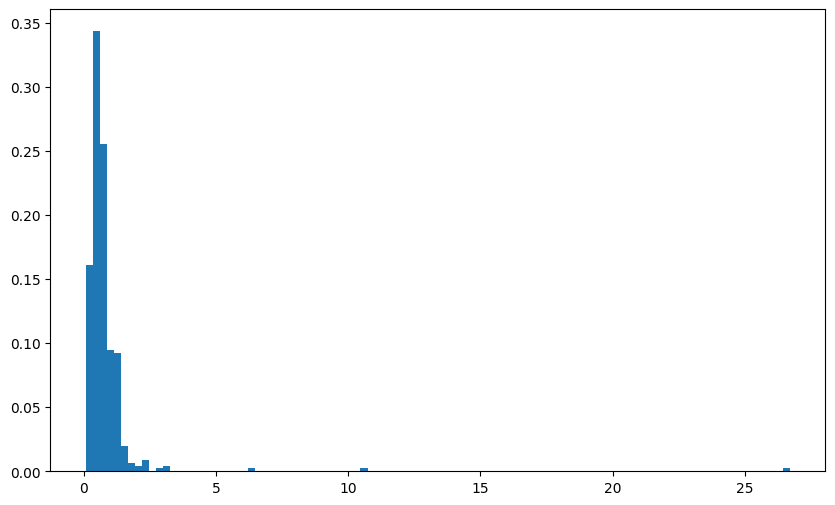

In [ ]:
# Extract and plot LIG CoM distances from mean CoM
from xaidar.data.protocols import extract_lig_from_prot
import numpy as np
ligs, ligs_datasets,  logs = extract_lig_from_prot( piperid_dir, coord = get_res_CoM( flatten_pdb( ref_lig, "residue" ) )[0] )
ligs_CoM = np.array([ np.array(get_res_CoM( flatten_pdb( lig, "residue") )[0]) if lig is not None else None for lig in ligs ])
print( ligs_CoM.shape)
mean_CoM = np.mean( ligs_CoM, axis = 0)
ligs_dist = [ np.linalg.norm( mean_CoM - lig_CoM ) for lig_CoM in ligs_CoM ]

import matplotlib.pyplot as plt

plt.figure( figsize=(10,6) )
bin = 100

plt.hist( x = ligs_dist, bins = bin, weights = np.ones_like( ligs_dist) / len( ligs_dist))
plt.show()

In [ ]:
# Remove Outliers and Recalculate Mean CoM
outlier_dataset_indexs = [ idx for idx, value in enumerate(ligs_dist) if value > 5]
standard_dataset_indexs = [ idx for idx, value in enumerate(ligs_dist) if value <= 5]
outlier_dataset_names = [ ligs_datasets[idx] for idx in outlier_dataset_indexs ]
print( outlier_dataset_names )
updated_mean_CoM = np.mean( [ ligs_CoM[idx] for idx in standard_dataset_indexs] , axis = 0)
# New Refined Iteration of LIG Extraction
ligs, ligs_datasets,  logs = extract_lig_from_prot( piperid_dir, coord = updated_mean_CoM )
ref_prot = sele_pdb( sele_pdb( ref_obj, sele_AA ), sele_closest_Chain, gemmi.Position( *updated_mean_CoM) )
ligs_CoM = np.array([ np.array(get_res_CoM( flatten_pdb( lig, "residue") )[0]) if lig is not None else None for lig in ligs ])
updated_mean_CoM = np.mean( ligs_CoM, axis = 0)
ligs_res_lst = [ flatten_pdb( lig, "residue")[0] for lig in ligs ]
print( mean_CoM )
print( updated_mean_CoM.tolist() )
print( ligs_res_lst[:5])

['A5359b', 'A4596b', 'A4967c']
[ 8.93416454 13.28037812 23.31114499]
[8.934164544349706, 13.280378115795903, 23.311144986636997]
[<gemmi.Residue 201(LIG) with 28 atoms>, <gemmi.Residue 201(LIG) with 20 atoms>, <gemmi.Residue 201(LIG) with 20 atoms>, <gemmi.Residue 201(LIG) with 21 atoms>, <gemmi.Residue 201(LIG) with 18 atoms>]


In [ ]:
# GPT function to compute pairwise distances -> pairwise_distances

# coords1: array-like shape (N,3)
# coords2: array-like shape (M,3)
# returns distances matrix shape (N, M) where entry [i,j] is ||coords1[i] - coords2[j]||
def pairwise_distances(coords1, coords2):
    coords1 = np.asarray(coords1)
    coords2 = np.asarray(coords2)
    # broadcasting subtraction -> (N,1,3) - (1,M,3) -> (N,M,3)
    diff = coords1[:, None, :] - coords2[None, :, :]
    return np.linalg.norm(diff, axis=2)

# # Example (using variables already in the notebook)
# # ligs_CoM has shape (454,3), lig_atoms_pos has shape (14,3)
# ref_lig_atoms = flatten_pdb( ref_lig, "atom" )
# lig_atoms_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  ref_lig_atoms] )
# dists = pairwise_distances(lig_atoms_pos, lig_atoms_pos)
# print(dists.shape)   # (454, 14)
# print( np.min( dists) )

# # distances from the first coord in ligs_CoM to all coords in lig_atoms_pos
# import matplotlib.pyplot as plt
# import seaborn as sns

# labels = [atom.name for atom in ref_lig_res]  # atom names for ticks
# plt.figure(figsize=(9, 7))
# ax = sns.heatmap(dists, xticklabels=labels, yticklabels=labels,
#                  cmap="viridis", annot=True, fmt=".2f",
#                  cbar_kws={"label": "Distance (Å)"})
# ax.set_title("Pairwise atom distances (Å)")
# plt.xticks(rotation=45, ha="right")
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()


(14, 14)
0.0


In [ ]:
# Extracting AAs within 5A of any LIG atom

from collections import defaultdict
aa_set = set()
aa_per_dataset = defaultdict( list)

for chain in ref_prot[0]:
    res_CoMs = get_res_CoM( chain.whole() )
    res_lst  = [ res for idx, res in enumerate(chain.whole()) if np.linalg.norm( res_CoMs[idx] - updated_mean_CoM) < 15.0 ]
    for prot_res in res_lst:
        res_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  prot_res] )
        for lig_res, lig_dataset_name in zip(ligs_res_lst,ligs_datasets ):
          lig_atom_pos = np.array( [  np.array( [atom.pos.x,atom.pos.y, atom.pos.z] ) for atom in  lig_res] )
          if np.min( pairwise_distances(res_atom_pos, lig_atom_pos) ) < 5.0:
              aa_set.add( prot_res )
              aa_per_dataset[lig_dataset_name].append( prot_res )  


In [68]:
# print( sorted( [ (res.name, res.seqid.num) for res in aa_set ], key= lambda x: x[1]) )
print( sorted( [ res.seqid.num for res in aa_set ] ) )

[21, 22, 39, 82, 83, 84, 85, 86, 87, 88, 89, 90, 93, 94, 95, 98, 100, 104, 105, 106, 107, 108, 109, 110, 124, 125, 126, 127, 128, 129, 131, 132, 133]


---

In [4]:
active_site = [('21', 'HIS'), ('39', 'ASP'), ('84', 'VAL'), ('87', 'SER'),
                ('89', 'TYR'), ('90', 'TYR'), ('95', 'GLN'), ('107', 'PRO'),
                ('125', 'SER'), ('126', 'THR'), ('127', 'GLY'), ('128', 'GLY')]


In [5]:
double_prot =  gemmi.read_pdb( str( next( piperid_dir.joinpath("A5879a").glob( "??????.pdb" ) ) ) )
get_pdb_stats( double_prot )


####################
Number of models: 1
Number of chains in 1st Model: 7

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: {'LIG'}
	Contains A.A.
Chain ID: B
	Number of Residues: 1
	Unique List of Non-A.A.: {'ZN'}
Chain ID: C
	Number of Residues: 140
	Unique List of Non-A.A.: {'LIG'}
	Contains A.A.
Chain ID: E
	Number of Residues: 1
	Unique List of Non-A.A.: {'ZN'}
Chain ID: F
	Number of Residues: 1
	Unique List of Non-A.A.: {'DMS'}
Chain ID: H
	Number of Residues: 8
	Unique List of Non-A.A.: {'HOH'}
Chain ID: W
	Number of Residues: 10
	Unique List of Non-A.A.: {'HOH'}


- ## Side Quest: Check difference in ligand conformation in duplicated protein

In [6]:
from xaidar.data.molecModels import sele_pdb, sele_Lig, flatten_pdb, get_res_CoM, model_seqAlign, structAlign, sele_chain_idx

ref_chain = sele_pdb( sele_pdb( double_prot, sele_AA ), sele_chain_idx, [0])
ref_lig = sele_pdb( sele_pdb( double_prot, sele_Lig ), sele_chain_idx, [0])
mobile_chain = sele_pdb( sele_pdb( double_prot, sele_AA ), sele_chain_idx, [1])
mobile_lig = sele_pdb( sele_pdb( double_prot, sele_Lig ), sele_chain_idx, [1])
# get_pdb_stats( mobile_lig)
transform = structAlign( ref_chain, mobile_chain ).calc_transform().transform
print( get_res_CoM( flatten_pdb( mobile_chain, "residue" ) )[0] )
flatten_pdb( mobile_lig, "chain" )[0].whole().transform_pos_and_adp( transform )
flatten_pdb( mobile_chain, "chain" )[0].whole().transform_pos_and_adp( transform )
print( get_res_CoM( flatten_pdb( mobile_chain, "residue" ) )[0] )

transform_pdb = ref_chain.clone()
transform_pdb[0].add_chain( flatten_pdb(mobile_chain, "chain")[0] )
transform_pdb[0]["A"].add_residue( flatten_pdb(ref_lig, "residue")[0] )
transform_pdb[0]["C"].add_residue( flatten_pdb(mobile_lig, "residue")[0] )

get_pdb_stats( transform_pdb )
save_Path = Path( "./tmp/edited/double_prot.pdb" )
save_Path.parent.mkdir( exist_ok=True, parents=True )
transform_pdb.write_pdb( str( save_Path ) )

[ 11.08305853 -24.19738447   8.70165008]
[19.14015626  5.63802832 24.78339205]

####################
Number of models: 1
Number of chains in 1st Model: 2

Chain ID: A
	Number of Residues: 140
	Unique List of Non-A.A.: {'LIG'}
	Contains A.A.
Chain ID: C
	Number of Residues: 140
	Unique List of Non-A.A.: {'LIG'}
	Contains A.A.


---

In [7]:
# from typing import Callable
# from copy import deepcopy
# from xaidar.data.molecModels import  clear_empty

# def sele_pdb(pdb: gemmi.Structure, selection : Callable, 
#                         *args, level: str = None, **kwargs) -> gemmi.Structure:
#     """
#     Perform filtering on a PDB structure based on a specified level and selection.
#     Used to access a specific level of the gemmi.Structure hierarchy and filter
#     elements at that level using a provided selection function.
#     Args:
#     - pdb (gemmi.Structure): The PDB structure to filter.
#     - level (str): The level of filtering ('model', 'chain', 'residue', 'atom').
#     - selection (function): A function that takes an element of the specified level
#       and additional arguments, returning True if the element should be included.
#       - *args: Additional arguments to pass to the selection function.
#       Returns:
#       - list: A list of elements that meet the filtering selection.
#     """
#     level = selection( pdb, *args, level = True, **kwargs) if level is None else level
#     empty_pdb = deepcopy( pdb )                                                     # Store Object of models
#     while len(empty_pdb) > 0: del empty_pdb[0]                                      # Remove everything except Structure level info
#     new_pdb = empty_pdb                                                             # Create new Structure Object to Store selected elements
#     print( "new_pdb type:", type(new_pdb))
#                                                                                     # Looking at models
#     if level == 'model': 
#         sele_models = selection( pdb, *args, **kwargs)                              # -> list[ gemmi.Model ]
#         for sele_model in sele_models:
#             new_pdb.add_model( sele_model )                                         # Fill Structure with selected Model Objects
#     else:
#         for model_id, model in enumerate(pdb):
#             empty_model = gemmi.Model(model_id + 1 )                                # Add Model attribute .num
#             new_pdb.add_model( empty_model )                                        # Create Model Object without chains (empty)
#                                                                                     # Looking a chains
#             new_model = new_pdb[-1]                                                 # Call Last Empty Model Object to Store chains in
#             if level == 'chain': 
#                 sele_chains = selection( model, *args, **kwargs)                    # -> list[ gemmi.Chain ]
#                 for sele_chain in sele_chains:
#                     new_model.add_chain( sele_chain )
#             else:
#                 for chain in model:
#                     empty_chain = gemmi.Chain(chain.name)
#                     new_model.add_chain( empty_chain )                              # Create Chain Object without residues
#                                                                                     # Looking at residues 
#                     new_chain = new_model[chain.name]                               # Call Emtpy Chain Object to Store residue Objects in 
#                     if level == 'residue':
#                         sele_residues = selection( chain, *args, **kwargs)          # list[ gemmi.Residue ]
#                         for sele_residue in sele_residues: 
#                             new_chain.add_residue( sele_residue )
#                     else:
#                         for residue in chain:
#                             empty_res = deepcopy( residue )
#                             while len( empty_res) > 0 : del empty_res[0]            # Only keep residue level info, delete all atoms
#                             new_chain.add_residue( empty_res )                      # Create Residue Object without atoms
#                                                                                     # Looking at atoms                          
#                             new_residue = new_chain[-1]                             # Store Object of atoms
#                             if level == 'atom':
#                                 sele_atoms = selection( residue, *args, **kwargs)   # list[ gemmi.Atom ]
#                                 for sele_atom in sele_atoms:
#                                     new_residue.add_atom( sele_atom )
#                             else:
#                                 raise ValueError(("Invalid level specified. "
#                             "Choose from 'model', 'chain', 'residue', or 'atom'."))
#                                                                                     # Remove empty Models, Chains, Residues from resulting Structure    
#     new_pdb = clear_empty(new_pdb)
#     print( "nonempty new_pdb type:", type(new_pdb))

#     return new_pdb

# def sele_chain_idx( model: list[gemmi.Chain], lst_idx = [0],level = False, sort = True ):
#     if level: return "chain"
#     chain_names = [ chain.name for chain in model ]  
#     if sort:  sorted( chain_names)                  # Ensure alphabetical order
#     lst_chains = [ model[chain_name] for chain_name in chain_names ]
#     return [ lst_chains[idx] for idx in lst_idx ]


In [8]:
gemmi.Position( 1,1,1).tolist()

[1.0, 1.0, 1.0]

In [9]:
from xaidar.data.molecModels import model_seqAlign, structAlign, resList_to_resSpan, sele_res_idx
double_prot =  gemmi.read_pdb( str( next( piperid_dir.joinpath("A5879a").glob( "??????.pdb" ) ) ) )
ligs = []
ligs = sele_pdb( double_prot, sele_Lig)
# get_pdb_stats( ligs )
lig = flatten_pdb( ligs, "residue" )[0]
print( lig)
double_prot[0]["A"].whole().add_residue( lig, pos = 0 )
# flatten_pdb(ref_lig, "residue")[0].name = "Ref_LIG"
double_prot[0]["A"].whole().add_residue( flatten_pdb(ref_lig, "residue")[0] , pos = 0 )
# get_pdb_stats( double_prot)

### Process Ligands
lig_residues =  sele_pdb( double_prot, sele_Lig)
# num_ligs = len( flatten_pdb( lig_residues, "residue" ) )
# print( "Num Ligs: ", num_ligs )
# get_pdb_stats( lig_residues )
# lig_objs = []
# for chain in lig_residues[0]:
#     lig_objs = lig_objs + []
# ligs_obj = [ sele_pdb( lig_residues, sele_res_idx, [ (idx,idx+1)], slice_within = False) for idx in range( num_ligs ) ]
# print( "Ligs Obj: ", ligs_obj )
ligs_res = flatten_pdb( sele_pdb( double_prot, sele_Lig), "residue" )
# empty_chain = 


ligs_obj = []
from copy import deepcopy
empty_pdb = deepcopy( lig_residues )                                                     # Store Object of models
while len(empty_pdb) > 0: del empty_pdb[0]                                      # Remove everything except Structure level info
new_pdb = empty_pdb  
for model in lig_residues:
    for model_id, model in enumerate(lig_residues):
        empty_model = gemmi.Model(model_id + 1 )                                # Add Model attribute .num
        new_pdb.add_model( empty_model )  
        new_model = new_pdb[-1] 
        for chain in model:
            empty_chain = gemmi.Chain(chain.name)
            new_model.add_chain( empty_chain )                              # Create Chain Object without residues
            new_chain = new_model[chain.name]
            for residue in chain:
                new_chain.add_residue( residue )
                ligs_obj.append( new_pdb.clone())
                del new_chain[-1]






lig_chains = [ res.subchain[0] for res in ligs_res ]
ligs_CoMs = get_res_CoM( ligs_res )
ligs = { idx: {"obj": obj, "res": res, "chain": chain, "CoM": CoM} for idx,  (obj, res, chain, CoM) in                     
                            enumerate( zip(ligs_obj, ligs_res, lig_chains, ligs_CoMs) ) }
print( "Lig Res: ", ligs_res)
# print( "Lig Chains: ", lig_chains )
print( "Lig CoMs: ", ligs_CoMs )


### Process Proteins
prot_aa =  sele_pdb(double_prot, sele_AA )

prots_obj = [ sele_pdb( prot_aa, sele_chain_idx, [idx], sort = True) for idx in range( len(prot_aa[0]) ) ]
prots_chain = [ flatten_pdb( prot, "chain" )[0].name for prot in prots_obj ]


# prots = [ createPDB(chainList = [ sele_pdb(double_prot, sele_AA )[0]["A"]  ] ),
#          createPDB(chainList = [ sele_pdb(double_prot, sele_AA )[0]["C"]  ] )]
prots_CoM = []
prot = prots_obj[0]
for prot in prots_obj:
    align = model_seqAlign( ref_prot,prot  ).map_matching_res( match_type= "all") # .visualize()
    # print()
    ref_matched_res =  [ (res.seqid.num, res.name) for res in align.matched_res["Ref"] ]
    matched_indexes = [ query_res for ref_res, query_res in                             # Get query 3d cooredinates of active site residues in query
                            zip(align.matched_res["Ref"], align.matched_res["Query"])   
                            if (str(ref_res.seqid.num), ref_res.name) in active_site]   # Filter only active site residues
    active_site_CoM = [ float( num) for num in np.round(
                        np.mean( get_res_CoM( matched_indexes ) , axis=0 ), 5 )]
    prots_CoM.append( active_site_CoM )

prots = { idx: {"obj": prot, "chain": chain, "CoM": CoM }
                for idx, ( prot, chain, CoM) in 
                enumerate( zip(prots_obj, prots_chain, prots_CoM) ) }
# print("Prots Obj: ", prots_obj)
# print("Prot Chains: ", prots_chain )
print("Prot CoMs: ", prots_CoM )



### Find Closest Prot-Lig Pairs
prot_lig_pair = []
shortest_prot_lig_pair = None
for lig_idx, lig_CoM in enumerate(ligs_CoMs):
    prot_lig_pair.append(None)
    smallest_dist = 1e6
    for prot_idx, prot_activesite_CoM in enumerate(prots_CoM):
        dist = gemmi.Position( *lig_CoM).dist( gemmi.Position(*prot_activesite_CoM  ) )
        smallest_dist = min(dist, smallest_dist)
        if dist == smallest_dist:
            prot_lig_pair[-1] = (lig_idx,  prot_idx, round(dist, 4))
    if shortest_prot_lig_pair is None or prot_lig_pair[-1][-1] < shortest_prot_lig_pair[-1]:
        shortest_prot_lig_pair = prot_lig_pair[-1]                              # Update Shortest Prot-Lig Pair (if there is several of the same distance, it just pick the first one)

print("Closest Prot Indexes - [LigIDX, ProtIDX, Dist] :", prot_lig_pair )
print("Shortest Prot-Lig Pair: ", shortest_prot_lig_pair )

print()
## Get Alignment Reference and Mobile Proteins and Ligands
align_ref_prot = prots[shortest_prot_lig_pair[1] ]["obj"]
align_ref_prot_chain = prots[shortest_prot_lig_pair[1] ]["chain"]
print( "Align Ref Prot Chain: ", align_ref_prot_chain )
mobile_prots = [ prots[idx]["obj"] for idx in prots.keys() if idx != shortest_prot_lig_pair[1] ]
mobile_prots_idx = [ idx for idx in prots.keys() if idx != shortest_prot_lig_pair[1] ]
mobile_prots_chains = [ prots[idx]["chain"] for idx in prots.keys() if idx != shortest_prot_lig_pair[1] ]
print( "Mobile Prots Chains: ", mobile_prots_chains)
print( "Mobile Prots Idx: ", mobile_prots_idx)
prot_to_lig_map = { prot_idx: [] for   prot_idx in prots.keys()} # Remap for prot chain closest to ligand
for lig_idx, prot_idx, _ in prot_lig_pair: prot_to_lig_map[prot_idx].append( lig_idx )
mobile_ligs = [ [ ligs_obj[lig_idx] for lig_idx in prot_to_lig_map[prot_idx] ] for prot_idx in mobile_prots_idx ]
mobile_ligs_CoM = [ [ ligs_CoMs[lig_idx] for lig_idx in prot_to_lig_map[prot_idx] ] for prot_idx in mobile_prots_idx ]
print( "Mobile Ligs Idx: ", mobile_ligs)
print( "Mobile Ligs CoM: ", mobile_ligs_CoM)



# print("###################")
# print( get_res_CoM( flatten_pdb( mobile_ligs[0][1], "residue") ) )
# transform = structAlign( align_ref_prot, mobile_prots[0] ).calc_transform().transform
# print( transform.vec, transform.mat )
# flatten_pdb( mobile_ligs[0][1], "chain")[0].whole().transform_pos_and_adp( transform )
# print( get_res_CoM( flatten_pdb( mobile_ligs[0][1], "residue") ) )
# print("###################")
# for lig in ligs_obj:
#     print( get_res_CoM( flatten_pdb(lig, "residue") ) )

# Align Mobile Proteins to Reference and Transform Corresponding Ligands

    # V1 -> Does not work
# for mobile_prot, lst_mobile_ligs in zip( mobile_prots, mobile_ligs):
#     transform = structAlign( align_ref_prot, mobile_prot ).calc_transform().transform
#     for lig in lst_mobile_ligs:
#         flatten_pdb(lig, "chain")[0].whole().transform_pos_and_adp( transform )


    #V2 -> Works
for mobile_prot, lst_mobile_ligs in zip( mobile_prots, mobile_ligs):
    transform = structAlign( align_ref_prot, mobile_prot ).calc_transform().transform
    rot_mat = np.array( transform.mat.array)
    trans_vec = np.array( [transform.vec.x, transform.vec.y, transform.vec.z ] )
    for lig in lst_mobile_ligs:
        mobile_lig_res = flatten_pdb(lig, "residue")[0]
        for atom in mobile_lig_res:
            coord = np.array(atom.pos.tolist())
            new_coord = coord @ rot_mat.T + trans_vec
            atom.pos = gemmi.Position( *new_coord.tolist() )



print("###################")
for lig in ligs_obj:
    print( get_res_CoM( flatten_pdb(lig, "residue") ) )

# print( prot_to_lig_map)
# [ [ ligs[lig_idx]["obj"] for lig_idx in ligs.keys() if ligs[lig_idx]["obj"] ] for prot_chain in mobile_prots_chains ]

# mobile_ligs = [ [ ligs_obj[lig_idx] for lig_idx, prot_idx, _ in prot_lig_pair if prot_idx != shortest_prot_lig_pair[1] ] ]
# mobile_ligs_idx = [ lig_idx for lig_idx, prot_idx, _ in prot_lig_pair if prot_idx != shortest_prot_lig_pair[1] ]
# print( "Mobile Ligs Idx: ", mobile_ligs_idx)
# mobile_ligs = ligs_obj[ :shortest_prot_lig_pair[0] ] + ligs_obj[ shortest_prot_lig_pair[0] + 1 :]


# mobile_ligs  = chain # resList_to_resSpan(mobile_ligs)
# print( "Mobile Ligs Res: ", mobile_ligs)
# print("Align Ref Prot: ", align_ref_prot )
# print("Mobile Prots: ", mobile_prots )
# print("Mobile Ligs: ", mobile_ligs )
# mobile_prot = mobile_prots[0]
# transform = structAlign( ref_prot, mobile_prot ).calc_transform().transform
# mobile_ligs.whole().transform_pos_and_adp( transform)
# for res in mobile_ligs:
#     print( get_res_CoM( [res] ) )
# print()

# # print( type(transform.vec.x) )
# rot_mat = np.array( transform.mat.array)
# trans_vec = np.array( [transform.vec.x, transform.vec.y, transform.vec.z ] )
# print("Rotation Matrix: \n", rot_mat)
# print("Translation Vector: \n", trans_vec)
# print()

# ligs_CoMs = np.array( [ np.array(val) for val in ligs_CoMs ] )
# print("Lig CoMs before transform: \n", ligs_CoMs)
# transform_ligs_CoMs = ligs_CoMs @ rot_mat.T + trans_vec
# print("Lig CoMs after transform: \n", transform_ligs_CoMs)
# print()
# for res in flatten_pdb( sele_pdb( double_prot, sele_Lig), "residue" ):
#     print( get_res_CoM( [res]))
    




201(LIG)
Lig Res:  [<gemmi.Residue 201(LIG) with 29 atoms>, <gemmi.Residue 201(LIG) with 29 atoms>, <gemmi.Residue 201(LIG) with 29 atoms>, <gemmi.Residue 201(LIG) with 29 atoms>]
Lig CoMs:  [[ 23.58514978 -18.45549145   7.90670401]
 [  6.95236369  12.77166311  24.36140374]
 [ 23.58514978 -18.45549145   7.90670401]
 [  6.95236369  12.77166311  24.36140374]]
Prot CoMs:  [[10.14814, 14.66787, 20.59251], [21.51195, -16.7297, 12.3748]]
Closest Prot Indexes - [LigIDX, ProtIDX, Dist] : [(0, 1, 5.2192), (1, 0, 5.2927), (2, 1, 5.2192), (3, 0, 5.2927)]
Shortest Prot-Lig Pair:  (0, 1, 5.2192)

Align Ref Prot Chain:  C
Mobile Prots Chains:  ['A']
Mobile Prots Idx:  [0]
Mobile Ligs Idx:  [[<gemmi.Structure A5879a with 1 model(s)>, <gemmi.Structure A5879a with 1 model(s)>]]
Mobile Ligs CoM:  [[array([ 6.95236369, 12.77166311, 24.36140374]), array([ 6.95236369, 12.77166311, 24.36140374])]]
###################
[[ 23.58514978 -18.45549145   7.90670401]]
[[ 24.12149085 -18.77573515   8.23893166]]
[[ 23

In [10]:
# Input -> double_prot and ref_prot
from xaidar.data.molecModels import model_seqAlign, structAlign, resList_to_resSpan, sele_res_idx
double_prot =  gemmi.read_pdb( str( next( piperid_dir.joinpath("A5879a").glob( "??????.pdb" ) ) ) )
ligs = []
ligs = sele_pdb( double_prot, sele_Lig)
lig = flatten_pdb( ligs, "residue" )[0]
double_prot[0]["A"].whole().add_residue( lig, pos = 0 )
double_prot[0]["A"].whole().add_residue( flatten_pdb(ref_lig, "residue")[0] , pos = 0 )


### Process Ligands -> 
lig_residues =  sele_pdb( double_prot, sele_Lig)
ligs_res = flatten_pdb( sele_pdb( double_prot, sele_Lig), "residue" )
lig_chains = [ res.subchain[0] for res in ligs_res ]
ligs_CoMs = get_res_CoM( ligs_res )
ligs_obj = []
from copy import deepcopy
empty_pdb = deepcopy( lig_residues )                                                     # Store Object of models
while len(empty_pdb) > 0: del empty_pdb[0]                                      # Remove everything except Structure level info
new_pdb = empty_pdb  
for model in lig_residues:
    for model_id, model in enumerate(lig_residues):
        empty_model = gemmi.Model(model_id + 1 )                                # Add Model attribute .num
        new_pdb.add_model( empty_model )  
        new_model = new_pdb[-1] 
        for chain in model:
            empty_chain = gemmi.Chain(chain.name)
            new_model.add_chain( empty_chain )                              # Create Chain Object without residues
            new_chain = new_model[chain.name]
            for residue in chain:
                new_chain.add_residue( residue )
                ligs_obj.append( new_pdb.clone())
                del new_chain[-1]

ligs = { idx: {"obj": obj, "res": res, "chain": chain, "CoM": CoM} for idx,  (obj, res, chain, CoM) in                     
                            enumerate( zip(ligs_obj, ligs_res, lig_chains, ligs_CoMs) ) }

### Process Proteins
prot_aa =  sele_pdb(double_prot, sele_AA )
prots_obj = [ sele_pdb( prot_aa, sele_chain_idx, [idx], sort = True) for idx in range( len(prot_aa[0]) ) ]
prots_chain = [ flatten_pdb( prot, "chain" )[0].name for prot in prots_obj ]
prots_CoM = []

def get_active_site_CoM( ref_prot, query_prot, active_site ):
    for prot in prots_obj:
        align = model_seqAlign( ref_prot, prot).map_matching_res( match_type= "all") # .visualize()
        ref_matched_res =  [ (res.seqid.num, res.name) for res in align.matched_res["Ref"] ]
        matched_indexes = [ query_res for ref_res, query_res in                             # Get query 3d cooredinates of active site residues in query
                                zip(align.matched_res["Ref"], align.matched_res["Query"])   
                                if (str(ref_res.seqid.num), ref_res.name) in active_site]   # Filter only active site residues
        active_site_CoM = [ float( num) for num in np.round(
                            np.mean( get_res_CoM( matched_indexes ) , axis=0 ), 5 )]
        prots_CoM.append( active_site_CoM )

for prot in prots_obj:
    align = model_seqAlign( ref_prot, prot).map_matching_res( match_type= "all") # .visualize()
    ref_matched_res =  [ (res.seqid.num, res.name) for res in align.matched_res["Ref"] ]
    matched_indexes = [ query_res for ref_res, query_res in                             # Get query 3d cooredinates of active site residues in query
                            zip(align.matched_res["Ref"], align.matched_res["Query"])   
                            if (str(ref_res.seqid.num), ref_res.name) in active_site]   # Filter only active site residues
    active_site_CoM = [ float( num) for num in np.round(
                        np.mean( get_res_CoM( matched_indexes ) , axis=0 ), 5 )]
    prots_CoM.append( active_site_CoM )

prots = { idx: {"obj": prot, "chain": chain, "CoM": CoM }
                for idx, ( prot, chain, CoM) in 
                enumerate( zip(prots_obj, prots_chain, prots_CoM) ) }
# print("Prots Obj: ", prots_obj)
# print("Prot Chains: ", prots_chain )
print("Prot CoMs: ", prots_CoM )



### Find Closest Prot-Lig Pairs
prot_lig_pair = []
shortest_prot_lig_pair = None
for lig_idx, lig_CoM in enumerate(ligs_CoMs):
    prot_lig_pair.append(None)
    smallest_dist = 1e6
    for prot_idx, prot_activesite_CoM in enumerate(prots_CoM):
        dist = gemmi.Position( *lig_CoM).dist( gemmi.Position(*prot_activesite_CoM  ) )
        smallest_dist = min(dist, smallest_dist)
        if dist == smallest_dist:
            prot_lig_pair[-1] = (lig_idx,  prot_idx, round(dist, 4))
    if shortest_prot_lig_pair is None or prot_lig_pair[-1][-1] < shortest_prot_lig_pair[-1]:
        shortest_prot_lig_pair = prot_lig_pair[-1]                              # Update Shortest Prot-Lig Pair (if there is several of the same distance, it just pick the first one)

print("Closest Prot Indexes - [LigIDX, ProtIDX, Dist] :", prot_lig_pair )
print("Shortest Prot-Lig Pair: ", shortest_prot_lig_pair )

print()
## Get Alignment Reference and Mobile Proteins and Ligands
align_ref_prot = prots[shortest_prot_lig_pair[1] ]["obj"]
align_ref_prot_chain = prots[shortest_prot_lig_pair[1] ]["chain"]
print( "Align Ref Prot Chain: ", align_ref_prot_chain )
mobile_prots = [ prots[idx]["obj"] for idx in prots.keys() if idx != shortest_prot_lig_pair[1] ]
mobile_prots_idx = [ idx for idx in prots.keys() if idx != shortest_prot_lig_pair[1] ]
mobile_prots_chains = [ prots[idx]["chain"] for idx in prots.keys() if idx != shortest_prot_lig_pair[1] ]
print( "Mobile Prots Chains: ", mobile_prots_chains)
print( "Mobile Prots Idx: ", mobile_prots_idx)
prot_to_lig_map = { prot_idx: [] for   prot_idx in prots.keys()} # Remap for prot chain closest to ligand
for lig_idx, prot_idx, _ in prot_lig_pair: prot_to_lig_map[prot_idx].append( lig_idx )
mobile_ligs = [ [ ligs_obj[lig_idx] for lig_idx in prot_to_lig_map[prot_idx] ] for prot_idx in mobile_prots_idx ]
mobile_ligs_CoM = [ [ ligs_CoMs[lig_idx] for lig_idx in prot_to_lig_map[prot_idx] ] for prot_idx in mobile_prots_idx ]
print( "Mobile Ligs Idx: ", mobile_ligs)
print( "Mobile Ligs CoM: ", mobile_ligs_CoM)






Prot CoMs:  [[10.14814, 14.66787, 20.59251], [21.51195, -16.7297, 12.3748]]
Closest Prot Indexes - [LigIDX, ProtIDX, Dist] : [(0, 1, 5.2192), (1, 0, 5.2927), (2, 1, 5.2192), (3, 0, 5.2927)]
Shortest Prot-Lig Pair:  (0, 1, 5.2192)

Align Ref Prot Chain:  C
Mobile Prots Chains:  ['A']
Mobile Prots Idx:  [0]
Mobile Ligs Idx:  [[<gemmi.Structure A5879a with 1 model(s)>, <gemmi.Structure A5879a with 1 model(s)>]]
Mobile Ligs CoM:  [[array([ 6.95236369, 12.77166311, 24.36140374]), array([ 6.95236369, 12.77166311, 24.36140374])]]


---

In [11]:
# Find multi-protein multi-ligand cases


dir_names = ["nonactivesite", "fragscreen", "piperid"]
dir_objects = [ nonactivepdbs_dir, fragscreen_dir, piperid_dir ]
all_counts = {}
for pdb_dir, dir_name in zip( dir_objects, dir_names ):
    count_dict = {"single_aa": [], "single_lig":[], "multi_lig":[]}
    for session_dir in pdb_dir.iterdir():
        if session_dir.is_dir():
            session_name = session_dir.name
            prot_file = session_dir / f"{session_name}.pdb"
            prot_pdb = gemmi.read_pdb( str( prot_file) )
            num_aa_chains = len(flatten_pdb( sele_pdb(prot_pdb, sele_AA), "chain" ))
            num_lig_chains = len(flatten_pdb( sele_pdb(prot_pdb, sele_Lig), "chain" ))
            if num_aa_chains > 1 and num_lig_chains > 1:
                count_dict["multi_lig"].append( session_name )
            elif num_aa_chains >1 and num_lig_chains == 1:
                count_dict["single_lig"].append( session_name )
            elif num_aa_chains == 1 and num_lig_chains ==1:
                count_dict["single_aa"].append( session_name )
            else:
                raise ValueError("Unaccounted case found!: ", session_name)
    all_counts[ dir_name ] = count_dict
    print( "\nLooking at: ", dir_name)
    print( "Multi Prot, Multi Lig: ",sorted(count_dict["multi_lig"] ) )
    print( "Multi Prot Single Lig",sorted(count_dict["single_lig"] ))
    print( "Single Prot Single Lig:", sorted(count_dict["single_aa"] ))


Looking at:  nonactivesite
Multi Prot, Multi Lig:  ['A5381a', 'A5381b', 'A5721a', 'A7465a', 'A7475a', 'A7491a', 'A7501a', 'A7510a', 'A7533a']
Multi Prot Single Lig ['A0514b', 'A1293a', 'A5721b', 'A7465b', 'A7475b', 'A7491b', 'A7501b', 'A7510b', 'A7533b']
Single Prot Single Lig: ['A0152a', 'A0152b', 'A0188a', 'A0194a', 'A0202a', 'A0202b', 'A0228a', 'A0229a', 'A0229b', 'A0239a', 'A0269a', 'A0278a', 'A0278b', 'A0305a', 'A0309a', 'A0332a', 'A0333a', 'A0341a', 'A0351b', 'A0351c', 'A0354a', 'A0359a', 'A0375a', 'A0375c', 'A0379a', 'A0395a', 'A0395b', 'A0396a', 'A0412a', 'A0428a', 'A0432a', 'A0469a', 'A0486a', 'A0488a', 'A0497a', 'A0515b', 'A0517a', 'A0525a', 'A0528b', 'A0540a', 'A0541a', 'A0554b', 'A0571a', 'A0586a', 'A0608a', 'A0691a', 'A0717a', 'A0719b', 'A0831a', 'A0836b', 'A0853a', 'A0863a', 'A0875b', 'A0900a', 'A0922a', 'A1068a', 'A1068b', 'A1068c', 'A1081a', 'A1081b', 'A1084a', 'A1105a', 'A1105b', 'A1109a', 'A1128a', 'A1145a', 'A1145b', 'A1146a', 'A1148b', 'A2448a', 'A2458a', 'A3181b',

In [17]:
all_counts_num = {}
for dir_name in dir_names:
    all_counts_num[ dir_name ] = { key: len( all_counts[dir_name][key] ) for key in all_counts[dir_name].keys() }
print( "\nSummary of Counts: \n", all_counts_num )
all_counts_num["Total"] = { key: sum( all_counts_num[dir_name][key] for dir_name in dir_names ) for key in all_counts[ dir_names[0] ].keys() }
print( "\nSummary of Counts: \n", all_counts_num )
# print( "\nOverall Summary of Counts: \n", all_counts_num["Total"] ) for key in all_counts[ dir_names[0] ].keys() }  
import pandas as pd
df_counts = pd.DataFrame( all_counts_num ).T
display( df_counts )


Summary of Counts: 
 {'nonactivesite': {'single_aa': 81, 'single_lig': 9, 'multi_lig': 9}, 'fragscreen': {'single_aa': 27, 'single_lig': 12, 'multi_lig': 3}, 'piperid': {'single_aa': 185, 'single_lig': 100, 'multi_lig': 169}}

Summary of Counts: 
 {'nonactivesite': {'single_aa': 81, 'single_lig': 9, 'multi_lig': 9}, 'fragscreen': {'single_aa': 27, 'single_lig': 12, 'multi_lig': 3}, 'piperid': {'single_aa': 185, 'single_lig': 100, 'multi_lig': 169}, 'Total': {'single_aa': 293, 'single_lig': 121, 'multi_lig': 181}}


,single_aa,single_lig,multi_lig
nonactivesite,81,9,9
fragscreen,27,12,3
piperid,185,100,169
Total,293,121,181


- ### Multi Prot Multi Lig

Simplest:

- Pick a Protein, move all the ligands to that protien

Level2:

- Pick the Protein surrounded by most ligands

In [12]:
nonact_multi_lig = all_counts["nonactivesite"]["multi_lig"]

for session_dir in nonactivepdbs_dir.iterdir():
    if session_dir.is_dir() and session_dir.name in nonact_multi_lig[:1]:
        session_name = session_dir.name
        prot_file = session_dir / f"{session_name}.pdb"
        prot_pdb = gemmi.read_pdb( str( prot_file) )
        lig_pdb = sele_pdb( prot_pdb, sele_Lig)
        lig_chains = flatten_pdb( lig_pdb, "chain" )
        lig_chains_to_CoM = { chain.name: chain.calculate_center_of_mass() for chain in lig_chains }
        print( lig_chains_to_CoM)
        print("Lig: ", lig_list)
        prot_aas = sele_pdb(prot_pdb, sele_AA)
        prot_chains = flatten_pdb( prot_aas, "chain" )
        prot_chains_to_CoM = { chain.name: chain.calculate_center_of_mass() for chain in prot_chains }
       

{'B': <gemmi.Position(5.75815, 1.12129, -1.22259)>, 'A': <gemmi.Position(9.39873, 11.6145, 27.2893)>}


NameError: name 'lig_list' is not defined

In [ ]:
test_prot = gemmi.read_pdb( str( nonactivepdbs_dir / "A5381a" / "A5381a.pdb") )

In [ ]:
[chain.name for chain in test_prot[0]]

['B', 'C', 'D', 'E', 'F', 'A', 'H', 'W']

In [ ]:
from xaidar.data.molecModels import sele_pdb, sele_chain_idx
from xaidar.data.molecModels import get_pdb_stats
get_pdb_stats( sele_pdb(test_prot, sele_chain_idx, [7]) )


####################
Number of models: 1
Number of chains in 1st Model: 1

Chain ID: W
	Number of Residues: 11
	Unique List of Non-A.A.: {'HOH'}


In [ ]:
from xaidar.data.molecModels import structAlign
def process_multi_prot_multi_lig(pdb, num_aa_chains ) -> dict:
    aa_chains = pdb.clone()
    aa_chains = sele_pdb( aa_chains, sele_AA )
    ref_chain = sele_pdb( aa_chains, sele_chain_idx, [0] )
    lst_mobile_chains = [ sele_pdb( aa_chains, sele_chain_idx, [idx] ) for idx in range(1, num_aa_chains) ]
    
    for mobile_chain, mobile_lig in zip( lst_mobile_chains, ):
        align_transform = structAlign( ref_chain, mobile_chain ).calc_transform().transform
        
        



---

In [ ]:
# Load Fragalysis data (nonactivepdbs_dir, fragscreen_dir, piperid_dir, ...)
from xaidar.data.protocols import load_and_filter_Proteins, extract_lig_from_prot
# 1. Loading Fragalyis data Root Directory
rootProjDir = rootdir / "data/ev2a/fragalysis"
fragalysisDir =  rootdir / "data/ev2a/fragalysis"

# 2. Load Fragalysis Protein Directories
nonactivepdbs_dir = fragalysisDir / "02-chemofint/nonactivesite"
fragscreen_dir = fragalysisDir / "02-chemofint/fragscreen"
piperid_dir = fragalysisDir / "02-chemofint/piperid"

# 3. Load Fragments
nonactive_ligs = extract_lig_from_prot( nonactivepdbs_dir )
fragscreen_ligs = extract_lig_from_prot( fragscreen_dir )
piperid_ligs = extract_lig_from_prot( piperid_dir )
all_ligs = nonactive_ligs + fragscreen_ligs + piperid_ligs

# print( "Extracted {} ligands from nonactivepdbs_dir".format(
#     sum( [ 1 for lig in nonactive_ligs if lig is not None ] ) ) )
# print( "Extracted {} ligands from fragscreen_dir".format(
#     sum( [ 1 for lig in fragscreen_ligs if lig is not None ] ) ) )
# print( "Extracted {} ligands from piperid_dir".format(
#     sum( [ 1 for lig in piperid_ligs if lig is not None ] ) ) )


# 4. Compute Mean CoM for each set of proteins for filtering
lst_ligs = [ flatten_pdb( lig_pdb, "residue")[0] for lig_pdb in all_ligs if lig_pdb is not None ]
CoM_array = get_res_CoM(  lst_ligs  )
mean_CoM = CoM_array.mean(axis=0)
mean_CoM = gemmi.Position( *mean_CoM )
# print( "Ligands CoM array shape: ", CoM_array.shape)
# print( "Mean CoM from all ligands: ",mean_CoM )

# 5. Load Fragalysis Protein Files
nonactive_prots, nonactive_logs = load_and_filter_Proteins( nonactivepdbs_dir, 
                                                                    mean_CoM )
fragscreen_prots, fragscreen_logs = load_and_filter_Proteins( fragscreen_dir, 
                                                                    mean_CoM )
piperid_prots, piperid_logs = load_and_filter_Proteins( piperid_dir, 
                                                                    mean_CoM )

# print( "Loaded {} proteins after filtering from nonactive".format( len(nonactive_prots) ) )
# print( "Loaded {} proteins after filtering from fragscreen".format( len(fragscreen_prots) ) )
# print( "Loaded {} proteins after filtering from piperid".format( len(piperid_prots) ) )  

ValueError: Error in extracting LIG from PDB: A7501a

- ## Check the variation in the proteins CoM

In [ ]:
# Compute Center of Mass for each protein set -> all_CoM_dict: {"nonactive":.., "fragscreen":.., "piperid":.., "all":..}
all_CoM_dict = {}
for prot_list, name in zip( [nonactive_prots, fragscreen_prots, piperid_prots], 
                            ["nonactive", "fragscreen", "piperid"] ):
    # print( "Processing CoM for {} proteins".format(name) )
    CoM_lst = []
    for prot in prot_list:
        chain = flatten_pdb( prot, "chain" )[0]
        chain_CoM = chain.calculate_center_of_mass()
        chain_CoM = [ chain_CoM.x, chain_CoM.y, chain_CoM.z ]
        CoM_lst.append( chain_CoM )
    all_CoM_dict[name] = np.array( CoM_lst  )

all_CoM = np.array( [np.array(item)  for lst in all_CoM_dict.values() for item in lst]   )
all_CoM_dict["all"] = all_CoM

# for name, CoM_array in all_CoM_dict.items():
#     print( "{} CoM array shape: {}".format( name, CoM_array.shape ) )

In [ ]:
# Calculate overall CoM and Variation -> all_CoM_data: { "name": {"data":..., "mean":..., "dist":...} }
all_CoM_data = {}

for name in  ["nonactive", "fragscreen", "piperid", "all"]:
    CoM_stats = {}
    CoM_data = all_CoM_dict[name]
    CoM_mean = np.mean( CoM_data, axis=0 )
    CoM_dist = np.linalg.norm( CoM_data - CoM_mean, axis=1 )
    CoM_stats["data"], CoM_stats["mean"], CoM_stats["dist"] = CoM_data, CoM_mean, CoM_dist
    all_CoM_data[name] = CoM_stats

# for name in ["nonactive", "fragscreen", "piperid", "all"]:
#     print("Prot Library: {}".format(name))
#     print("\tData: {}".format( all_CoM_data[name]["data"].shape))
#     print("\tMean: {}".format( all_CoM_data[name]["mean"].shape))
#     print("\tDist: {}".format( all_CoM_data[name]["dist"].shape))


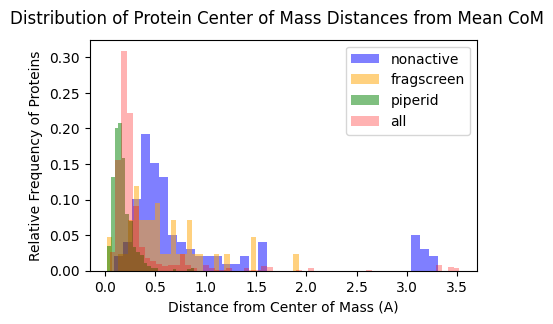

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots( 1,1, figsize = (5, 3), sharey=True, sharex = True )

for name, bin, color, alpha in  zip(["nonactive", "fragscreen", "piperid", "all"],
                         [0.6, 0.6, 0.4, 1],
                          ["blue", "orange", "green", "red"],
                           [0.5, 0.5, 0.5, 0.3] ): # [ 0,0,0,1] ): # 
    bin = int(60 * bin)
    CoM_dist = all_CoM_data[name]["dist"]
    ax.hist( CoM_dist, bins= bin, weights = np.ones_like(CoM_dist) / len(CoM_dist) ,label = name, alpha=alpha, color=color )
ax.set_ylabel( "Relative Frequency of Proteins")
ax.set_xlabel( "Distance from Center of Mass (A)")
ax.legend()
plt.suptitle( "Distribution of Protein Center of Mass Distances from Mean CoM" )
plt.show()

- ## Align All Proteins

1. Global Align
2. Refined Local Align

In [ ]:
# Select Reference Protein based on Minimum Distance from Mean CoM -> ref_prot
ref_prot_dict = {}
for name, prot_list in zip( ["nonactive", "fragscreen", "piperid"],
                            [nonactive_prots, fragscreen_prots, piperid_prots] ):
    CoM_dist = all_CoM_data[name]["dist"]
    min_idx = np.argmin( CoM_dist )
    min_CoM =  all_CoM_data[name]["dist"][ min_idx ]
    ref_prot = prot_list[ min_idx ]
    ref_prot_dict[name] = ref_prot
    print( "Reference Protein for {} selected: {}".format( name, (ref_prot.name, round(min_CoM,3) ) )    )

print( "Chosen Reference Protein: fragscreen - A0926a" )
ref_prot = ref_prot_dict["fragscreen"]

Reference Protein for nonactive selected: ('A0354a', np.float64(0.085))
Reference Protein for fragscreen selected: ('A0926a', np.float64(0.02))
Reference Protein for piperid selected: ('A3207a', np.float64(0.022))
Chosen Reference Protein: fragscreen - A0926a


In [ ]:
# Get Test Protein with Largest Com Distance from CoM Mean -> test_prot
test_prot_dict = {}
for name, prot_list in zip( ["nonactive", "fragscreen", "piperid"],
                            [nonactive_prots, fragscreen_prots, piperid_prots] ):
    CoM_dist = all_CoM_data[name]["dist"]
    max_idx = np.argmax( CoM_dist )
    max_CoM =  all_CoM_data[name]["dist"][ max_idx ]
    test_prot = prot_list[ max_idx ]
    test_prot_dict[name] = test_prot
    print( "Test Protein for {} selected: {}".format( name, (test_prot.name, round(max_CoM,3) ) )    )

print( "Chosen Test Protein: nonactive - A7501a" )
test_prot = test_prot_dict["nonactive"]


Test Protein for nonactive selected: ('A7501a', np.float64(3.309))
Test Protein for fragscreen selected: ('A0526a', np.float64(1.925))
Test Protein for piperid selected: ('A3222a', np.float64(0.888))
Chosen Test Protein: nonactive - A7501a


- #### Compute RMSD without Alignment

In [ ]:
# Compute RMSD without Alignment
from xaidar.data.molecModels import structAlign
["nonactive", "fragscreen", "piperid"]
[nonactive_prots, fragscreen_prots, piperid_prots]

rmsd_prots_dict_notalign = {}
for name, prot_list in zip( ["nonactive", "fragscreen", "piperid"],
                            [nonactive_prots, fragscreen_prots, piperid_prots] ):
    rmsd_prots = [structAlign( ref_prot, prot ).calc_rmsd().rmsd for prot in prot_list ]
    rmsd_prots_dict_notalign[name] = rmsd_prots

rmsd_prots_dict_notalign["all"] = []

for name in ["nonactive", "fragscreen", "piperid"]:
    rmsd_prots_dict_notalign["all"].extend( rmsd_prots_dict_notalign[name] )




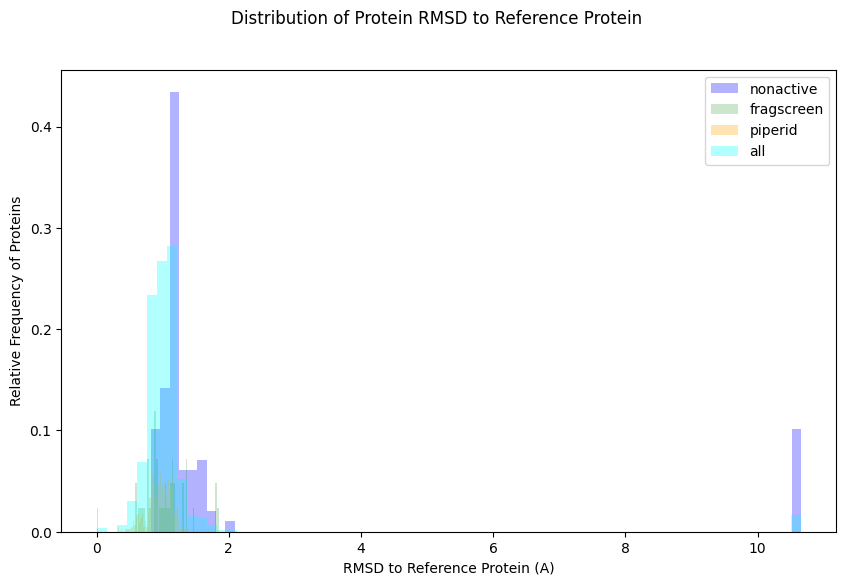

In [ ]:
import matplotlib.pyplot as plt

plt.figure( figsize= (10,6))
for name, color, bin, alpha in zip(
                    ["nonactive", "fragscreen", "piperid", "all"],
                    ["blue", "green", "orange", "cyan"],
                    [ 1,1,1,1],
                    [0.3,0.2,0.3,0.3,]                            ):
    bin = int(70 * bin)
    plt.hist(rmsd_prots_dict_notalign[name], bins = bin, color = color,
             alpha=alpha, label = name, 
             weights= np.ones_like(np.array(rmsd_prots_dict_notalign[name])) / len(rmsd_prots_dict_notalign[name]) ) 
plt.xlabel( "RMSD to Reference Protein (A)")
plt.ylabel( "Relative Frequency of Proteins")
plt.legend()
plt.suptitle( "Distribution of Protein RMSD to Reference Protein" )
plt.show()

- #### Align All Proteins to Reference Protein and Compute RMSD

In [ ]:
# Align All Proteins to Reference Protein and Compute RMSD
from xaidar.data.molecModels import structAlign
["nonactive", "fragscreen", "piperid"]
[nonactive_prots, fragscreen_prots, piperid_prots]

aligned_prots_dict = {}
rmsd_prots_dict = {}
for name, prot_list in zip( ["nonactive", "fragscreen", "piperid"],
                            [nonactive_prots, fragscreen_prots, piperid_prots] ):
    aligned_prots = [structAlign( ref_prot, prot ).align().aligned_prot for prot in prot_list ]
    rmsd_prots = [structAlign( ref_prot, prot ).align().rmsd for prot in prot_list ]
    aligned_prots_dict[name] = aligned_prots
    rmsd_prots_dict[name] = rmsd_prots

aligned_prots_dict["all"] = []
rmsd_prots_dict["all"] = []

for name in ["nonactive", "fragscreen", "piperid"]:
    aligned_prots_dict["all"].extend( aligned_prots_dict[name] )
    rmsd_prots_dict["all"].extend( rmsd_prots_dict[name] )

for name in ["nonactive", "fragscreen", "piperid", "all"]:
    print( "\t{} Aligned Proteins: {}".format( name, len( aligned_prots_dict[name] ) ) )


	nonactive Aligned Proteins: 99
	fragscreen Aligned Proteins: 42
	piperid Aligned Proteins: 454
	all Aligned Proteins: 595


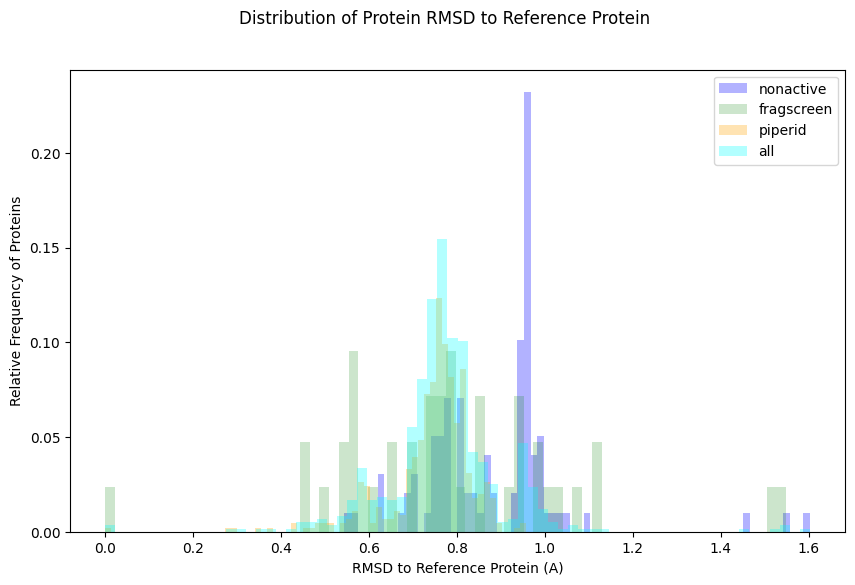

In [ ]:
import matplotlib.pyplot as plt

plt.figure( figsize= (10,6))
for name, color, bin, alpha in zip(
                    ["nonactive", "fragscreen", "piperid", "all"],
                    ["blue", "green", "orange", "cyan"],
                    [ 1,1,1,1],
                    [0.3,0.2,0.3,0.3,]                            ):
    bin = int(70 * bin)
    plt.hist(rmsd_prots_dict[name], bins = bin, color = color,
             alpha=alpha, label = name, 
             weights= np.ones_like(np.array(rmsd_prots_dict[name])) / len(rmsd_prots_dict[name]) ) 
plt.xlabel( "RMSD to Reference Protein (A)")
plt.ylabel( "Relative Frequency of Proteins")
plt.legend()
plt.suptitle( "Distribution of Protein RMSD to Reference Protein" )
plt.show()

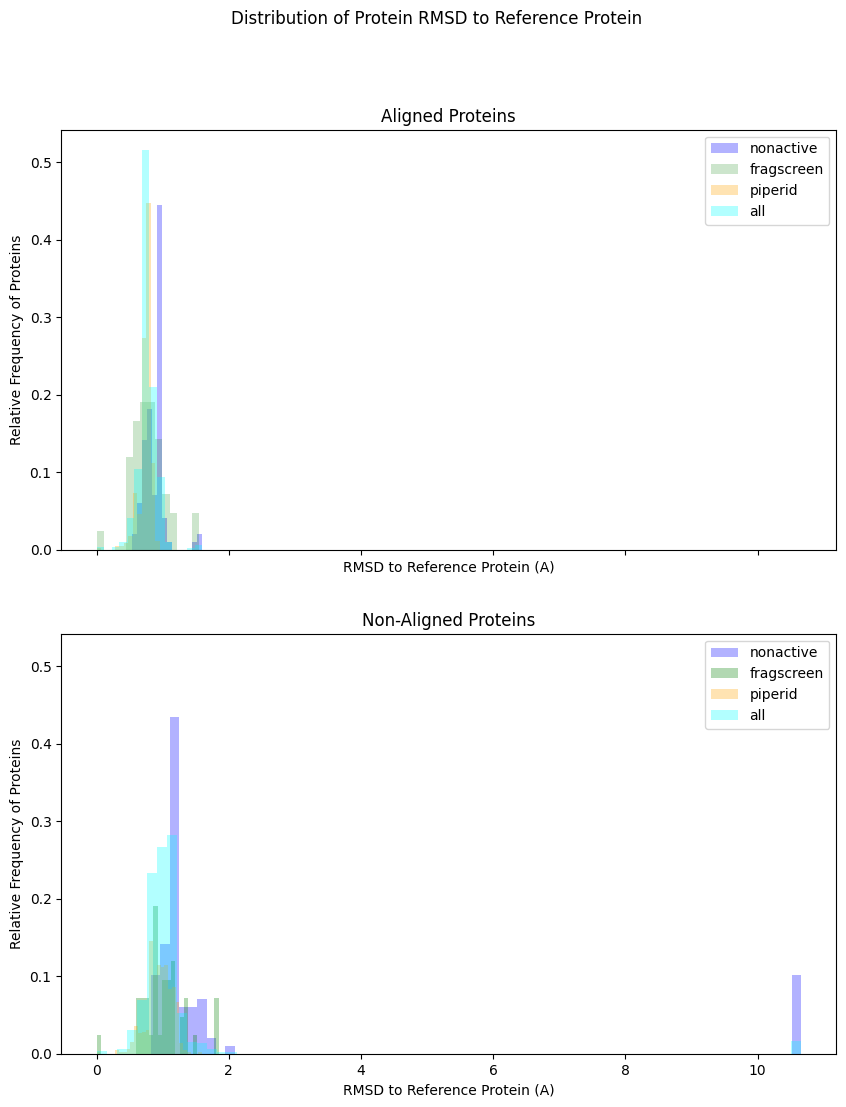

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots( 2, 1, figsize= (10,12), sharex=True, sharey=True)
for name, color, bin, alpha in zip(
                    ["nonactive", "fragscreen", "piperid", "all"],
                    ["blue", "green", "orange", "cyan"],
                    [ 0.2,0.2,0.2,0.2],
                    [0.3,0.2,0.3,0.3,]                            ):
    bin = int(70 * bin)
    ax[0].hist(rmsd_prots_dict[name], bins = bin, color = color,
             alpha=alpha, label = name, 
             weights= np.ones_like(np.array(rmsd_prots_dict[name])) / len(rmsd_prots_dict[name]) ) 

for name, color, bin, alpha in zip(
                    ["nonactive", "fragscreen", "piperid", "all"],
                    ["blue", "green", "orange", "cyan"],
                    [ 1,0.4,0.4,1],
                    [0.3,0.3,0.3,0.3,]                            ):
    bin = int(70 * bin)
    ax[1].hist(rmsd_prots_dict_notalign[name], bins = bin, color = color,
             alpha=alpha, label = name, 
             weights= np.ones_like(np.array(rmsd_prots_dict_notalign[name])) / len(rmsd_prots_dict_notalign[name]) ) 

for i in [0,1]:
    ax[i].set_xlabel( "RMSD to Reference Protein (A)")
    ax[i].set_ylabel( "Relative Frequency of Proteins")
    ax[i].legend()
    ax[i].set_title( "Aligned Proteins" if i==0 else "Non-Aligned Proteins" )
plt.suptitle( "Distribution of Protein RMSD to Reference Protein" )
plt.show()

- ## Calculate RMSD For each Res

### Figuring out calculating rmsd

- How to account for occupancies less than 1

In [ ]:
print( flatten_pdb(ref_prot, "residue"))
chain = gemmi.Chain("a")
chain.append_residues( flatten_pdb(ref_prot, "residue") )
print(chain.whole() )

[<gemmi.Residue 7(SER) with 6 atoms>, <gemmi.Residue 8(GLY) with 4 atoms>, <gemmi.Residue 9(ALA) with 5 atoms>, <gemmi.Residue 10(ILE) with 8 atoms>, <gemmi.Residue 11(TYR) with 12 atoms>, <gemmi.Residue 12(VAL) with 7 atoms>, <gemmi.Residue 13(GLY) with 4 atoms>, <gemmi.Residue 14(ASN) with 8 atoms>, <gemmi.Residue 15(TYR) with 12 atoms>, <gemmi.Residue 16(ARG) with 11 atoms>, <gemmi.Residue 17(VAL) with 7 atoms>, <gemmi.Residue 18(VAL) with 7 atoms>, <gemmi.Residue 19(ASN) with 8 atoms>, <gemmi.Residue 20(ARG) with 11 atoms>, <gemmi.Residue 21(HIS) with 10 atoms>, <gemmi.Residue 22(LEU) with 8 atoms>, <gemmi.Residue 23(ALA) with 5 atoms>, <gemmi.Residue 24(THR) with 7 atoms>, <gemmi.Residue 25(HIS) with 10 atoms>, <gemmi.Residue 26(ASN) with 8 atoms>, <gemmi.Residue 27(ASP) with 8 atoms>, <gemmi.Residue 28(TRP) with 14 atoms>, <gemmi.Residue 29(ALA) with 5 atoms>, <gemmi.Residue 30(ASN) with 8 atoms>, <gemmi.Residue 31(LEU) with 8 atoms>, <gemmi.Residue 32(VAL) with 7 atoms>, <gemmi.

In [ ]:
test_prot[0]["A"].whole().transform_pos_and_adp

In [ ]:
print(np.mean(np.array([(atom.pos.x,atom.pos.y,atom.pos.z) for atom in  flatten_pdb( test_prot, "residue")[0]]), axis=0)     )
flatten_pdb( test_prot, "chain")[0].whole().transform_pos_and_adp( supresult_after.transform )
print(np.mean(np.array([(atom.pos.x,atom.pos.y,atom.pos.z) for atom in  flatten_pdb( test_prot, "residue")[0]]), axis=0)     )


[22.10666667 13.30366667 25.0265    ]


NameError: name 'supresult_after' is not defined

In [ ]:
# rmse for a residue
from xaidar.data.molecModels import  model_seqAlign
align = model_seqAlign( ref_prot, test_prot).map_matching_res( )
ref_res = align.matched_res["Ref"]
test_res = align.matched_res["Query"]
print( "Number of Matched Residues: ", len(ref_res) )
print( "Number of Matched Residues: ", len(test_res) )

ref_num_atoms = [ len(res) for res in ref_res ]
test_num_atoms = [ len(res) for res in test_res ]
for i, (r_na, t_na) in enumerate( zip(ref_res, test_res) ):
    if len(r_na) != len(t_na):
        print( "Residue Index: {}, Ref Num Atoms: {}, Test Num Atoms: {}".format(i, len(r_na), len(t_na)) )


val_ref_res = ref_res[11]
print( val_ref_res.name, len( val_ref_res) )
val_ref_res_names = [ atom.name for atom in val_ref_res ]
val_test_res = test_res[11]
print( "Reference Residue Atoms: ", val_ref_res_names)
print( "Test Residue Atoms: ", [ atom.name for atom in val_test_res ] )

print( "Number of Atoms in Reference Residue: ", len([ atom.pos for atom in val_ref_res]) )
print( "Number of Atoms in Test Residue: ",len( [atom.pos for atom in val_test_res
                                    if atom.name in val_ref_res_names]) )

val_test_atom = [ atom for atom in val_test_res if atom.name == "CG2"]

print( val_test_atom[1].occ )
# rmsd = gemmi.superpose_positions( [ atom.pos for atom in val_ref_res], 
#                                     [atom.pos for atom in val_test_res
#                                     if atom.name in val_ref_res_names] ).rmsd

# print( rmsd)

# ref_res = flatten_pdb( ref_prot, "chain")[0].whole()[0]
# test_res = flatten_pdb( test_prot, "chain")[0].whole()[0]

# ref_at_pos_lst = [ atom.pos for atom in ref_res]
# test_at_pos_lst = [atom.pos for atom in test_res]
# print( ref_at_pos_lst,"\n", test_at_pos_lst)
# gemmi.superpose_positions( ref_at_pos_lst, test_at_pos_lst).rmsd


def get_res_rmsd( res_lst_1, res_lst_2):
    res_rmsd_lst = []
    
    for res_1, res_2 in zip( res_lst_1, res_lst_2):
        ref_res = [  res_1, res_2][ int(np.argmin([ len(res_1), len(res_2)]) ) ]
        ref_atom_lst = [ atom.name for atom in ref_res ]
        query_res = [  res_1, res_2][ int(np.argmax([ len(res_1), len(res_2)]) ) ]

        res_rmsd_lst.append( gemmi.superpose_positions( [ atom.pos for atom in ref_res], 
                                    [atom.pos for atom in query_res
                                    if atom.name in ref_atom_lst] ).rmsd)
                     
    return res_rmsd_lst



Number of Matched Residues:  135
Number of Matched Residues:  135
Residue Index: 11, Ref Num Atoms: 7, Test Num Atoms: 11
Residue Index: 29, Ref Num Atoms: 12, Test Num Atoms: 9
Residue Index: 58, Ref Num Atoms: 6, Test Num Atoms: 9
Residue Index: 66, Ref Num Atoms: 12, Test Num Atoms: 9
Residue Index: 75, Ref Num Atoms: 9, Test Num Atoms: 15
VAL 7
Reference Residue Atoms:  ['N', 'CA', 'C', 'O', 'CB', 'CG1', 'CG2']
Test Residue Atoms:  ['N', 'CA', 'CB', 'CG1', 'CG2', 'C', 'O', 'CA', 'CB', 'CG1', 'CG2']
Number of Atoms in Reference Residue:  7
Number of Atoms in Test Residue:  11
0.5


In [ ]:
int(np.argmin([5,0,1]))

1

In [ ]:
print( len(ref_res[5]))
print( [ atom.name for atom in ref_res[5] ])

TypeError: object of type 'Atom' has no len()

In [ ]:
ref_res = flatten_pdb( ref_prot, "residue")
query_res = flatten_pdb( test_prot, "residue")
rmsd_lst = get_res_rmsd(ref_res, query_res)
print(rmsd_lst)

RuntimeError: superpose_positions: pos1 and pos2 must have equal lengths